<a href="https://colab.research.google.com/github/coweye1/Gunshot_Wound_Entrance_vs_Exit_ViT_Benchmark/blob/main/Gunshot_Wound_Entrance_vs_Exit_ViT_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
# Step 1: Install necessary libraries and import modules
# 'timm' (PyTorch Image Models) provides easy access to SOTA ViT and Swin models.
!pip install timm
# 'torchmetrics' is used to calculate F1-Score and AUC-ROC as requested by Dr. Gitto.
!pip install torchmetrics

# 2. Basic Imports
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 3. PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

# 4. Torchvision & TIMM
import torchvision
from torchvision import datasets, models, transforms
import timm

# 5. Evaluation Metrics
# Following the revised abstract, we will monitor Accuracy, F1-Score, and AUC-ROC.
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC

# 6. Device Configuration
# L4 or A100 GPU is highly recommended for Transformer-based architectures.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"✅ Current device in use: {device}")

# Verify GPU Name (Ensure you are utilizing your purchased compute units)
if torch.cuda.is_available():
    print(f"🚀 GPU Model: {torch.cuda.get_device_name(0)}")

✅ Current device in use: cuda:0
🚀 GPU Model: Tesla T4


In [5]:
# Step 2: Extract the zip file for faster training
# Ensure the path matches your actual zip file location in Drive
zip_path = "/content/drive/MyDrive/Gunshot_Dataset_Final.zip"
extract_path = "/content/dataset"

if os.path.exists(zip_path):
    print("✅ Dataset found! Starting extraction...")
    !unzip -qo "{zip_path}" -d "{extract_path}"
    print("✨ Extraction complete!")
else:
    print("❌ Error: Dataset zip file not found in Drive. Please check the path.")

✅ Dataset found! Starting extraction...
✨ Extraction complete!


In [6]:
# Step 3: Data Preprocessing with "Center-Focus" Strategy

# ImageNet normalization parameters
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# "To preserve diagnostic detail while focusing on wound morphology,
# a 'Center-Focus' preprocessing strategy is applied." - Dr. Lorenzo Gitto
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224), # Core strategy to isolate morphological markers
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

# The extracted local path from Step 2
# Typically unzip creates a subfolder, adjust the path if necessary (e.g., '/content/dataset/Gunshot_Dataset')
local_data_dir = '/content/dataset'

image_datasets = {x: datasets.ImageFolder(os.path.join(local_data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# Using batch size 16 for T4 GPU stability with ViT/Swin models
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=16,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"✅ Success: Dataset loaded from local directory.")
print(f"📊 Target Classes: {class_names}")
print(f"🖼️ Images: Train ({dataset_sizes['train']}), Val ({dataset_sizes['val']})")

✅ Success: Dataset loaded from local directory.
📊 Target Classes: ['entrance', 'exit']
🖼️ Images: Train (1787), Val (382)


In [7]:
# Step 4: Weighted Loss Algorithm to mitigate class imbalance
from collections import Counter

# 1. Count samples in each class from the training dataset
train_labels = [label for _, label in image_datasets['train'].samples]
class_counts = Counter(train_labels)
print(f"📊 Class counts in training set: {dict(class_counts)}")

# 2. Calculate inverse frequency weights
# Dr. Gitto's point: "Class weights are derived from inverse class frequencies"
total_samples = sum(class_counts.values())
# Normalizing weights so the majority class has weight 1.0 or similar
class_weights = [total_samples / class_counts[i] for i in range(len(class_names))]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"⚖️ Computed weights for [Entrance, Exit]: {class_weights}")

# 3. Define the Weighted Cross-Entropy Loss
# This ensures the model doesn't ignore the minority class (Exit wounds)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("✅ Weighted Cross-Entropy Loss defined successfully.")

📊 Class counts in training set: {0: 1318, 1: 469}
⚖️ Computed weights for [Entrance, Exit]: [1.3558421851289832, 3.810234541577825]
✅ Weighted Cross-Entropy Loss defined successfully.


In [9]:
# Step 5: Professional Training Function with F1-Score & AUC-ROC
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Initialize Metrics
    metric_acc = BinaryAccuracy().to(device)
    metric_f1 = BinaryF1Score().to(device)
    metric_auroc = BinaryAUROC().to(device)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.append(preds)
                all_labels.append(labels)

            if phase == 'train':
                scheduler.step()

            # Concatenate all results for metric calculation
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_preds = torch.cat(all_preds)
            epoch_labels = torch.cat(all_labels)

            # Calculate Advanced Metrics (Dr. Gitto's request)
            acc = metric_acc(epoch_preds, epoch_labels)
            f1 = metric_f1(epoch_preds, epoch_labels)

            # AUC-ROC calculation (requires probabilities, simplified here for binary)
            auroc = metric_auroc(epoch_preds.float(), epoch_labels)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {acc:.4f} F1: {f1:.4f} AUC: {auroc:.4f}')

            if phase == 'val' and acc > best_acc:
                best_acc = acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model

In [82]:
# --- Step 6-1: ViT-Small Training & Serialization ---
# Goal: Train the model and save the best weights to a specific Google Drive path.

import os

m_name = 'vit_small_patch16_224'
print(f"🔥 Starting Section: {m_name}")

# 1. Initialize Model, Optimizer, and Scheduler
# Using AdamW for stable Transformer training
model_vit = timm.create_model(m_name, pretrained=True, num_classes=2).to(device)
optimizer = optim.AdamW(model_vit.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 2. Execute Training Pipeline
trained_vit = train_model(model_vit, criterion, optimizer, scheduler, num_epochs=10)

# 3. Secure Serialization to Google Drive
# Target Directory: GSW_Project/Models/
save_dir = "/content/drive/MyDrive/GSW_Project/Models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"GSW_{m_name}.pth")

torch.save(trained_vit.state_dict(), save_path)
print(f"💾 Successfully saved {m_name} weights to: {save_path}")

🔥 Starting Section: vit_small_patch16_224

Epoch 0/9
----------
train Loss: 0.6918 Acc: 0.6111 F1: 0.4363 AUC: 0.5990
val Loss: 0.5686 Acc: 0.6518 F1: 0.5778 AUC: 0.7351

Epoch 1/9
----------
train Loss: 0.4630 Acc: 0.7739 F1: 0.6487 AUC: 0.7808
val Loss: 0.4615 Acc: 0.8665 F1: 0.7330 AUC: 0.8128

Epoch 2/9
----------
train Loss: 0.3553 Acc: 0.8327 F1: 0.7249 AUC: 0.8351
val Loss: 0.3670 Acc: 0.8508 F1: 0.7489 AUC: 0.8505

Epoch 3/9
----------
train Loss: 0.2743 Acc: 0.8892 F1: 0.8081 AUC: 0.8892
val Loss: 0.3971 Acc: 0.7880 F1: 0.6943 AUC: 0.8306

Epoch 4/9
----------
train Loss: 0.2181 Acc: 0.9127 F1: 0.8458 AUC: 0.9127
val Loss: 0.3970 Acc: 0.9162 F1: 0.8367 AUC: 0.8852

Epoch 5/9
----------
train Loss: 0.1664 Acc: 0.9362 F1: 0.8844 AUC: 0.9341
val Loss: 0.5445 Acc: 0.8979 F1: 0.7869 AUC: 0.8405

Epoch 6/9
----------
train Loss: 0.1468 Acc: 0.9440 F1: 0.8980 AUC: 0.9421
val Loss: 0.5234 Acc: 0.8822 F1: 0.7514 AUC: 0.8170

Epoch 7/9
----------
train Loss: 0.0666 Acc: 0.9815 F1: 0.965

✅ Model weights loaded from /content/drive/MyDrive/GSW_Project/Models/GSW_vit_small_patch16_224.pth
🔄 Generating Confusion Matrix for: vit_small_patch16_224


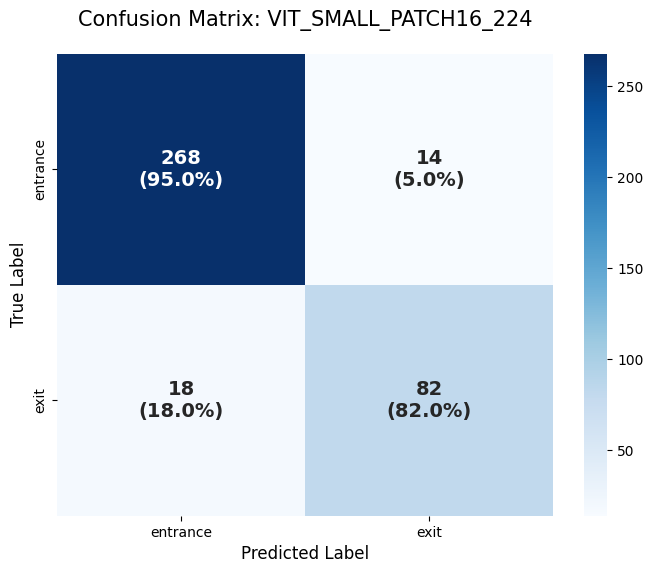

✅ Saved: CM_vit_small_patch16_224.png
              precision    recall  f1-score   support

    entrance       0.94      0.95      0.94       282
        exit       0.85      0.82      0.84       100

    accuracy                           0.92       382
   macro avg       0.90      0.89      0.89       382
weighted avg       0.92      0.92      0.92       382

------------------------------


In [83]:
# --- Step 6-2: Confusion Matrix via Saved Weights ---
# Goal: Load the saved model to evaluate quantitative performance (Entrance vs Exit).

# 1. Load the Model Architecture
eval_model_vit = timm.create_model(m_name, pretrained=False, num_classes=2).to(device)

# 2. Load State Dict from Google Drive
load_path = f"/content/drive/MyDrive/GSW_Project/Models/GSW_{m_name}.pth"
eval_model_vit.load_state_dict(torch.load(load_path))
eval_model_vit.eval()
print(f"✅ Model weights loaded from {load_path}")

# 3. Generate Benchmark Confusion Matrix
# This ensures visual validation of recall and precision for forensic classes.
generate_benchmark_cm(eval_model_vit, m_name, dataloaders['val'])

🔬 Analyzing Forensic Evidence: DISTANCIA_2017.0292SH17.38PCTEWNTTYDXSN02F01_EQX.JPG


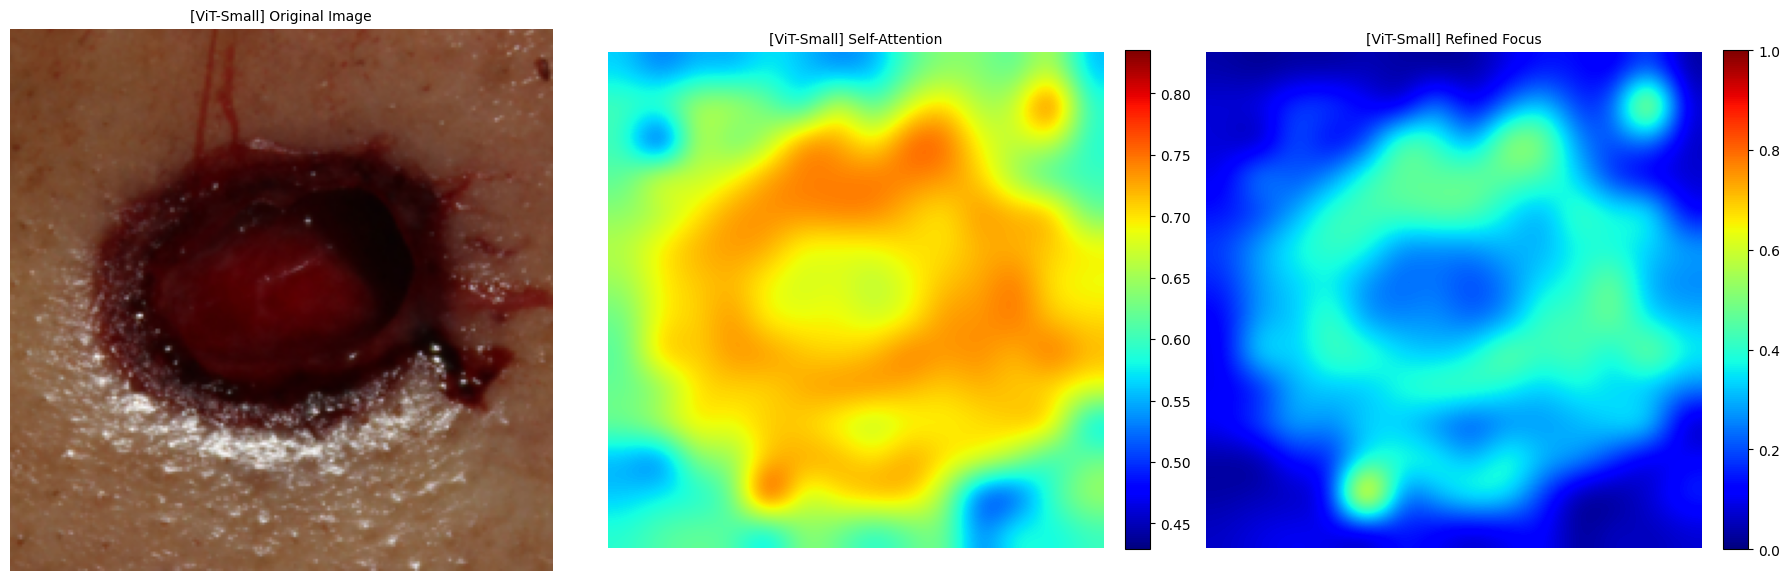

In [95]:
# --- Step 6-3: Forensic Interpretability (Attention Mapping) ---
# Goal: Visualize the diagnostic logic using Self-Attention and Refined focus with Model Labeling.

import glob
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def run_vit_dual_visualization_labeled(model, img_path, model_name="ViT-Small"):
    """
    Comparison of Simple Self-Attention and Refined Attention with dynamic labeling.
    """
    model.eval()

    # 1. Image Preprocessing
    rgb_img = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = data_transforms['val'](rgb_img).unsqueeze(0).to(device)

    # 2. Attention Feature Extraction
    with torch.no_grad():
        features = model.forward_features(input_tensor)
        cls_token = features[:, 0, :]
        patches = features[:, 1:, :]

        # Calculate Cosine Similarity for the final layer attention
        self_attn = torch.nn.functional.cosine_similarity(cls_token.unsqueeze(1), patches, dim=-1)
        self_attn = self_attn.reshape(14, 14).cpu().numpy()

    # 3. Triple-Panel Visualization with Dynamic Titles
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Panel A: Original Image
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"[{model_name}] Original Image", fontsize=10)
    axes[0].axis('off')

    # Panel B: Self-Attention (Global Context)
    im1 = axes[1].imshow(self_attn, cmap='jet', interpolation='bicubic')
    axes[1].set_title(f"[{model_name}] Self-Attention", fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel C: Refined Focus (Forensic Marker)
    # Applying cubic scaling for contrast enhancement
    norm_attn = (self_attn - self_attn.min()) / (self_attn.max() - self_attn.min())
    refined_attn = np.power(norm_attn, 3)

    im2 = axes[2].imshow(refined_attn, cmap='jet', interpolation='bicubic')
    axes[2].set_title(f"[{model_name}] Refined Focus", fontsize=10)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def run_vit_benchmarking_visualization(model, base_path='/content/dataset/val'):
    """
    Core execution function to find a random image and trigger the labeled visualization.
    """
    extensions = ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']
    all_image_paths = []
    for ext in extensions:
        all_image_paths.extend(glob.glob(os.path.join(base_path, '**', ext), recursive=True))

    if all_image_paths:
        sample_path = random.choice(all_image_paths)
        print(f"🔬 Analyzing Forensic Evidence: {os.path.basename(sample_path)}")

        # Correctly passing 'model_name' to the updated internal function
        run_vit_dual_visualization_labeled(model, sample_path, model_name="ViT-Small")
    else:
        print("❌ No forensic images found in the specified directory.")

# --- Execution ---
run_vit_benchmarking_visualization(eval_model_vit)

In [86]:
# --- Step 7-1: Swin-Transformer Training & Serialization ---
# Goal: Train the Swin-tiny model and save weights to the GSW_Project directory.

import os

m_name_swin = 'swin_tiny_patch4_window7_224'
print(f"🔥 Starting Section: {m_name_swin}")

# 1. Initialize Swin Model, Optimizer, and Scheduler
# Swin requires specific window-based attention handling, AdamW is ideal.
model_swin = timm.create_model(m_name_swin, pretrained=True, num_classes=2).to(device)
optimizer_swin = optim.AdamW(model_swin.parameters(), lr=1e-4, weight_decay=0.05)
scheduler_swin = lr_scheduler.StepLR(optimizer_swin, step_size=7, gamma=0.1)

# 2. Execute Training Pipeline
trained_swin = train_model(model_swin, criterion, optimizer_swin, scheduler_swin, num_epochs=10)

# 3. Secure Serialization to Google Drive
# Target Directory: GSW_Project/Models/
save_dir = "/content/drive/MyDrive/GSW_Project/Models"
os.makedirs(save_dir, exist_ok=True)
save_path_swin = os.path.join(save_dir, f"GSW_{m_name_swin}.pth")

torch.save(trained_swin.state_dict(), save_path_swin)
print(f"💾 Successfully saved Swin weights to: {save_path_swin}")

🔥 Starting Section: swin_tiny_patch4_window7_224

Epoch 0/9
----------
train Loss: 0.5142 Acc: 0.7443 F1: 0.5923 AUC: 0.7325
val Loss: 0.4731 Acc: 0.8770 F1: 0.7251 AUC: 0.7940

Epoch 1/9
----------
train Loss: 0.3636 Acc: 0.8405 F1: 0.7278 AUC: 0.8314
val Loss: 0.3678 Acc: 0.8613 F1: 0.7644 AUC: 0.8609

Epoch 2/9
----------
train Loss: 0.3006 Acc: 0.8808 F1: 0.7958 AUC: 0.8821
val Loss: 0.2980 Acc: 0.8639 F1: 0.7719 AUC: 0.8691

Epoch 3/9
----------
train Loss: 0.2650 Acc: 0.9026 F1: 0.8304 AUC: 0.9045
val Loss: 0.2959 Acc: 0.9005 F1: 0.8190 AUC: 0.8874

Epoch 4/9
----------
train Loss: 0.1939 Acc: 0.9306 F1: 0.8742 AUC: 0.9269
val Loss: 0.2625 Acc: 0.9162 F1: 0.8491 AUC: 0.9110

Epoch 5/9
----------
train Loss: 0.1562 Acc: 0.9368 F1: 0.8857 AUC: 0.9358
val Loss: 0.2868 Acc: 0.9241 F1: 0.8557 AUC: 0.9034

Epoch 6/9
----------
train Loss: 0.1396 Acc: 0.9530 F1: 0.9145 AUC: 0.9544
val Loss: 0.3202 Acc: 0.8743 F1: 0.7757 AUC: 0.8600

Epoch 7/9
----------
train Loss: 0.0841 Acc: 0.9743 F1

✅ Swin weights loaded from /content/drive/MyDrive/GSW_Project/Models/GSW_swin_tiny_patch4_window7_224.pth
🔄 Generating Confusion Matrix for: swin_tiny_patch4_window7_224


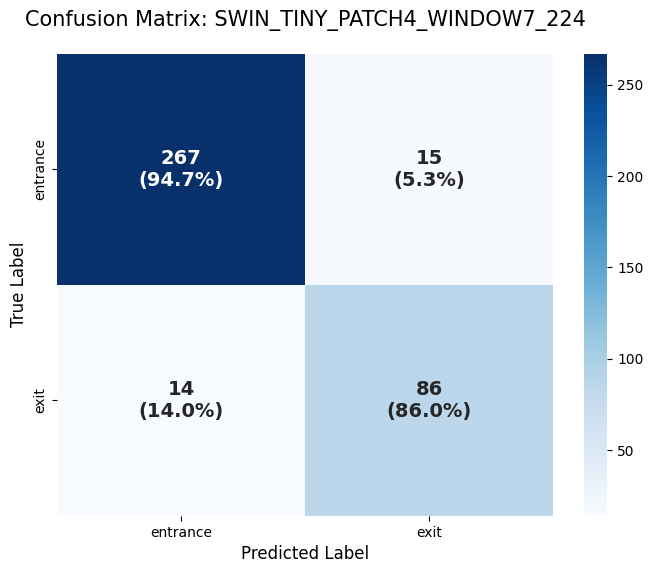

✅ Saved: CM_swin_tiny_patch4_window7_224.png
              precision    recall  f1-score   support

    entrance       0.95      0.95      0.95       282
        exit       0.85      0.86      0.86       100

    accuracy                           0.92       382
   macro avg       0.90      0.90      0.90       382
weighted avg       0.92      0.92      0.92       382

------------------------------


In [87]:
# --- Step 7-2: Swin Confusion Matrix via Saved Weights ---
# Goal: Load the saved Swin model to evaluate classification performance.

# 1. Load the Swin Architecture
eval_model_swin = timm.create_model(m_name_swin, pretrained=False, num_classes=2).to(device)

# 2. Load State Dict from Google Drive
load_path_swin = f"/content/drive/MyDrive/GSW_Project/Models/GSW_{m_name_swin}.pth"
eval_model_swin.load_state_dict(torch.load(load_path_swin))
eval_model_swin.eval()
print(f"✅ Swin weights loaded from {load_path_swin}")

# 3. Generate Benchmark Confusion Matrix
# Quantitative validation of Swin's hierarchical feature performance.
generate_benchmark_cm(eval_model_swin, m_name_swin, dataloaders['val'])

🔬 Analyzing Swin Evidence: DISTANCIA_2014.1332SH17.38PTTEWNTTYDXSN03F03_EQX.JPG


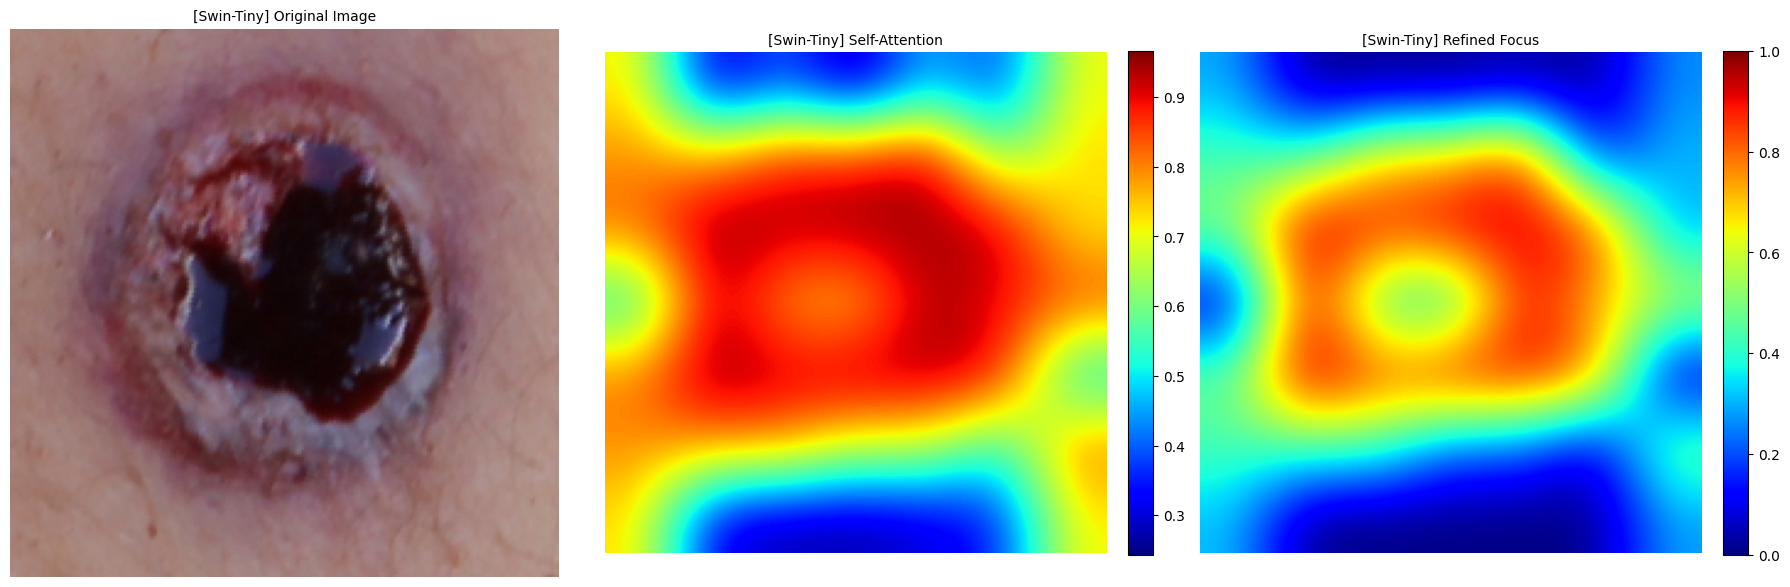

In [98]:
# --- Step 7-3: Swin Forensic Interpretability (Attention Mapping) ---
# Goal: Visualize Swin's hierarchical focus with dynamic Model Labeling.

def run_swin_dual_visualization_labeled(model, img_path, model_name="Swin-Tiny"):
    """
    Hierarchical attention visualization for Swin-Transformer with labeling.
    """
    model.eval()

    # 1. Preprocessing
    rgb_img = Image.open(img_path).convert('RGB').resize((224, 224))
    input_tensor = data_transforms['val'](rgb_img).unsqueeze(0).to(device)

    # 2. Hierarchical Feature Extraction
    with torch.no_grad():
        features = model.forward_features(input_tensor)
        global_context = features.mean(dim=1)
        spatial_patches = features

        self_attn = torch.nn.functional.cosine_similarity(global_context.unsqueeze(1), spatial_patches, dim=-1)
        self_attn = self_attn.reshape(7, 7).cpu().numpy()

    # 3. Triple-Panel Visualization with Dynamic Titles
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Panel A: Original
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"[{model_name}] Original Image", fontsize=10)
    axes[0].axis('off')

    # Panel B: Self-Attention
    im1 = axes[1].imshow(self_attn, cmap='jet', interpolation='bicubic')
    axes[1].set_title(f"[{model_name}] Self-Attention", fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel C: Refined Focus
    norm_attn = (self_attn - self_attn.min()) / (self_attn.max() - self_attn.min())
    refined_attn = np.power(norm_attn, 3)

    im2 = axes[2].imshow(refined_attn, cmap='jet', interpolation='bicubic')
    axes[2].set_title(f"[{model_name}] Refined Focus", fontsize=10)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def run_swin_benchmarking_visualization(model, base_path='/content/dataset/val'):
    """
    Executes Swin-specific visualization with clear model identification.
    """
    extensions = ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']
    all_image_paths = []
    for ext in extensions:
        all_image_paths.extend(glob.glob(os.path.join(base_path, '**', ext), recursive=True))

    if all_image_paths:
        sample_path = random.choice(all_image_paths)
        print(f"🔬 Analyzing Swin Evidence: {os.path.basename(sample_path)}")

        # Correctly passing 'model_name' to the updated internal function
        run_swin_dual_visualization_labeled(model, sample_path, model_name="Swin-Tiny")
    else:
        print("❌ No images found for Swin analysis.")

# --- Execution ---
run_swin_benchmarking_visualization(eval_model_swin)

In [103]:
"""

import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io
import os
import timm
import glob
from ipywidgets import FileUpload, Output, VBox, Dropdown, HTML
from IPython.display import display, clear_output

# --- 1. System Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path_root = '/content/drive/MyDrive/GSW_Project/Models'
class_names = ['Entrance', 'Exit']

# --- 2. Interactive UI Components ---
model_selector = Dropdown(
    options=[('ViT-Small (Global Context)', 'vit_small_patch16_224'),
             ('Swin-Tiny (Hierarchical Focus)', 'swin_tiny_patch4_window7_224')],
    value='vit_small_patch16_224',
    description='Select ViT:',
)

uploader = FileUpload(accept='image/*', multiple=False)
output_area = Output()

header_html = HTML("""
    <h2 style='color: #8B0000;'>🩸 GSW Transformer Forensic Analyzer</h2>
    <p>Upload a gunshot wound image to analyze <b>Entrance vs. Exit</b> using Vision Transformer (ViT) Attention mechanisms.</p>
""")

# --- 3. Attention Processing Core ---
def get_refined_attention(model, model_name, input_tensor):
    """
    Extracts and refines attention maps based on the selected architecture.
    """
    with torch.no_grad():
        features = model.forward_features(input_tensor)

        if 'vit' in model_name:
            # ViT-Small: CLS token similarity (14x14)
            cls_token = features[:, 0, :]
            patches = features[:, 1:, :]
            attn_map = torch.nn.functional.cosine_similarity(cls_token.unsqueeze(1), patches, dim=-1)
            attn_map = attn_map.reshape(14, 14).cpu().numpy()
        else:
            # Swin-Tiny: Hierarchical patch similarity (7x7)
            global_context = features.mean(dim=1)
            spatial_patches = features
            attn_map = torch.nn.functional.cosine_similarity(global_context.unsqueeze(1), spatial_patches, dim=-1)
            attn_map = attn_map.reshape(7, 7).cpu().numpy()

    # Normalize and apply contrast enhancement (Refined Focus)
    norm_attn = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    refined_attn = np.power(norm_attn, 3)
    return refined_attn

# --- 4. Main Diagnostic Logic ---
def run_transformer_analysis(change):
    with output_area:
        clear_output()
        if not uploader.value: return

        selected_m = model_selector.value
        print(f"⚙️ Loading {selected_m} weights for forensic analysis...")

        # Load Selected Transformer
        try:
            model = timm.create_model(selected_m, pretrained=False, num_classes=2).to(device)
            checkpoint_path = os.path.join(save_path_root, f'GSW_{selected_m}.pth')
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.eval()
        except Exception as e:
            print(f"❌ Error loading model: {e}\nCheck if GSW_{selected_m}.pth exists in your drive.")
            return

        # Process Uploaded Image
        file_info = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
        image_raw = Image.open(io.BytesIO(file_info['content'])).convert('RGB').resize((224, 224))

        # Preprocessing
        preprocess = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        input_tensor = preprocess(image_raw).unsqueeze(0).to(device)

        # 1. Inference & Confidence
        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output, dim=1)
            conf, pred_idx = torch.max(probs, dim=1)
            confidence = conf.item() * 100
            result_label = class_names[pred_idx.item()]

        # 2. Extract Refined Attention Map
        attn_heatmap = get_refined_attention(model, selected_m, input_tensor)

        # 3. Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 7))

        # Original Image
        axes[0].imshow(image_raw)
        axes[0].set_title(f"Original Forensic Image", fontsize=12)
        axes[0].axis('off')

        # Refined Attention Overlay
        # Using 'bicubic' to match clinical resolution
        im = axes[1].imshow(attn_heatmap, cmap='jet', interpolation='bicubic')
        axes[1].axis('off')

        # Result Header
        title_color = '#1E90FF' if result_label == 'Entrance' else '#FF4500'
        model_tag = "ViT-Small" if 'vit' in selected_m else "Swin-Tiny"

        title_text = f"[{model_tag}] Result: {result_label} ({confidence:.2f}%)\nAnalysis: Marginal Forensic Focus"
        axes[1].set_title(title_text, fontsize=16, color=title_color, fontweight='bold')

        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

        print(f"📋 Forensic Report: {model_tag} identified this as an '{result_label}' wound.")
        print(f"💡 Diagnostic Reasoning: The heatmap highlights the critical morphological regions used for this classification.")

# --- 5. UI Event Binding & Launch ---
uploader.observe(run_transformer_analysis, names='value')
display(VBox([header_html, model_selector, uploader, output_area]))



"""